# Facial Expression Recognition (FER) Using Custom CNN and ResNet-18 Architectures

---

## Project Overview
This project focuses on **Facial Expression Recognition (FER)** using the historical **FER2013** dataset. The goal is to accurately classify grayscale facial images into one of seven emotional categories: *Angry, Disgust, Fear, Happy, Sad, Surprise, and Neutral*.

To explore the problem effectively, we developed and compared two distinct deep learning methodologies:
1. A **Custom Baseline CNN** built from scratch to establish an initial performance benchmark.
2. A **ResNet-18 Architecture** leveraging deep residual learning and advanced optimization strategies.

---

## Phase 1: Data Acquisition and Exploratory Data Analysis (EDA)
In this phase, we securely download the FER2013 dataset directly from Kaggle to the local runtime disk. The original dataset provides images as space-separated pixel strings in a CSV file. We extract these strings, reconstruct the 48x48 pixel images, and organize them into standard `train`, `val`, and `test` directories.

In [ ]:
import torch
import numpy as np
import random
import os
import pandas as pd

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# LOCAL Path (lives on Colab's fast local disk)
LOCAL_BASE = '/content/fer2013_project'
os.makedirs(f'{LOCAL_BASE}/data', exist_ok=True)
os.makedirs(f'{LOCAL_BASE}/checkpoints', exist_ok=True)

# Deterministic seeds
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
print("Seeds set & local folders ready.")

Device: cuda
Seeds set & local folders ready.


**Upload the Kaggle credentials and download the correct dataset**

In [ ]:
from google.colab import files
files.upload()  # Upload your kaggle.json here

# Configure Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle ready.")

# Download and unzip directly to local scratch space
!kaggle datasets download -d deadskull7/fer2013 -p "{LOCAL_BASE}"
!unzip -q "{LOCAL_BASE}/fer2013.zip" -d "{LOCAL_BASE}"
print("Downloaded and unzipped locally!")

Saving kaggle.json to kaggle (1).json
Kaggle ready.
Dataset URL: https://www.kaggle.com/datasets/deadskull7/fer2013
License(s): CC0-1.0
fer2013.zip: Skipping, found more recently modified local copy (use --force to force download)
replace /content/fer2013_project/fer2013.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: Y
Downloaded and unzipped locally!


In [ ]:
# Load the local CSV
df = pd.read_csv(f'{LOCAL_BASE}/fer2013.csv')

print("Shape:", df.shape)               # Must be (35887, 3)
print("Columns:", df.columns.tolist())  # ['emotion', 'pixels', 'Usage']
print("\nSplit counts:")
print(df['Usage'].value_counts())
print("\nClass counts in training set:")
train_df = df[df['Usage'] == 'Training']
print(train_df['emotion'].value_counts().sort_index())

Shape: (35887, 3)
Columns: ['emotion', 'pixels', 'Usage']

Split counts:
Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64

Class counts in training set:
emotion
0    3995
1     436
2    4097
3    7215
4    4830
5    3171
6    4965
Name: count, dtype: int64


As we can appreciate, the FER2013 CSV file contains 35,887 samples, each with three fields: the emotion label, the pixel values of the 48×48 grayscale image, and the usage split (Training, PublicTest, or PrivateTest). The dataset is divided into 28,709 training images and two test partitions of 3,589 images each. This confirms that the dataset follows the standard FER2013 structure used in most benchmarks.

The class distribution in the training set is highly imbalanced. Some emotions such as Happy, Neutral, and Surprise have many more samples, while others like Disgust have very few. This imbalance makes the classification task more challenging, as the model tends to learn the majority classes more easily. Understanding this distribution is important because it explains why certain emotions are harder to classify and why techniques such as data augmentation, class weighting, or deeper architectures can significantly improve performance.

**Convert CSV to image files**

In [ ]:
from PIL import Image

emotion_labels = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
data_dir = f'{LOCAL_BASE}/data'

split_map = {
    'Training':    'train',
    'PublicTest':  'val',
    'PrivateTest': 'test'
}

# Create folder structure
for split in ['train', 'val', 'test']:
    for label in emotion_labels:
        os.makedirs(f'{data_dir}/{split}/{label}', exist_ok=True)

# Convert pixel strings to PNG files
for idx, row in df.iterrows():
    pixels = np.array(row['pixels'].split(), dtype=np.uint8).reshape(48, 48)
    img = Image.fromarray(pixels)
    split = split_map[row['Usage']]
    label = emotion_labels[row['emotion']]
    img.save(f'{data_dir}/{split}/{label}/{idx:05d}.png')
    if idx % 5000 == 0:
        print(f"  {idx}/{len(df)} processed...")

print("\nDone. Verifying counts:")
for split in ['train', 'val', 'test']:
    total = sum(len(os.listdir(f'{data_dir}/{split}/{lbl}')) for lbl in emotion_labels)
    print(f"  {split}: {total} images")

  0/35887 processed...
  5000/35887 processed...
  10000/35887 processed...
  15000/35887 processed...
  20000/35887 processed...
  25000/35887 processed...
  30000/35887 processed...
  35000/35887 processed...

Done. Verifying counts:
  train: 28709 images
  val: 3589 images
  test: 3589 images


This script converts the original FER2013 CSV file into a structured image dataset. Each row of the CSV contains a 48×48 grayscale image encoded as a long string of pixel values. The code reconstructs each image, saves it as a PNG file, and places it into the appropriate folder based on its emotion label and dataset split (train, validation, or test). After processing all samples, the script verifies that the number of generated images matches the expected counts from the CSV: 28,709 for training, 3,589 for validation, and 3,589 for testing. This confirms that the conversion was successful and that the dataset is now organized in a format compatible with PyTorch’s ImageFolder loader.

**Class distribution plot**

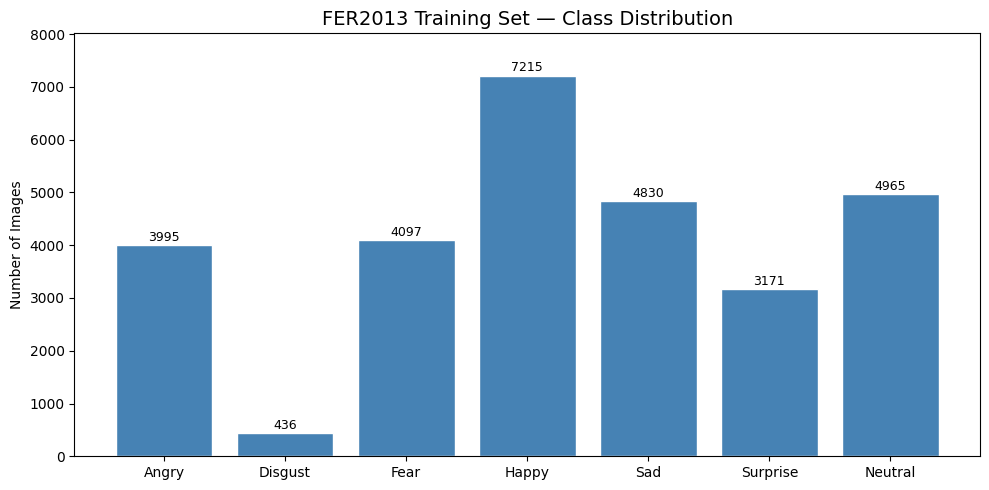

In [ ]:
import matplotlib.pyplot as plt

counts = train_df['emotion'].value_counts().sort_index()
emotion_labels_display = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

plt.figure(figsize=(10, 5))
bars = plt.bar(emotion_labels_display, counts.values, color='steelblue', edgecolor='white')
plt.title('FER2013 Training Set — Class Distribution', fontsize=14)
plt.ylabel('Number of Images')
plt.ylim(0, max(counts.values) + 800)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
             str(val), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{LOCAL_BASE}/class_distribution.png', dpi=150)
plt.show()

**Sample image grid**

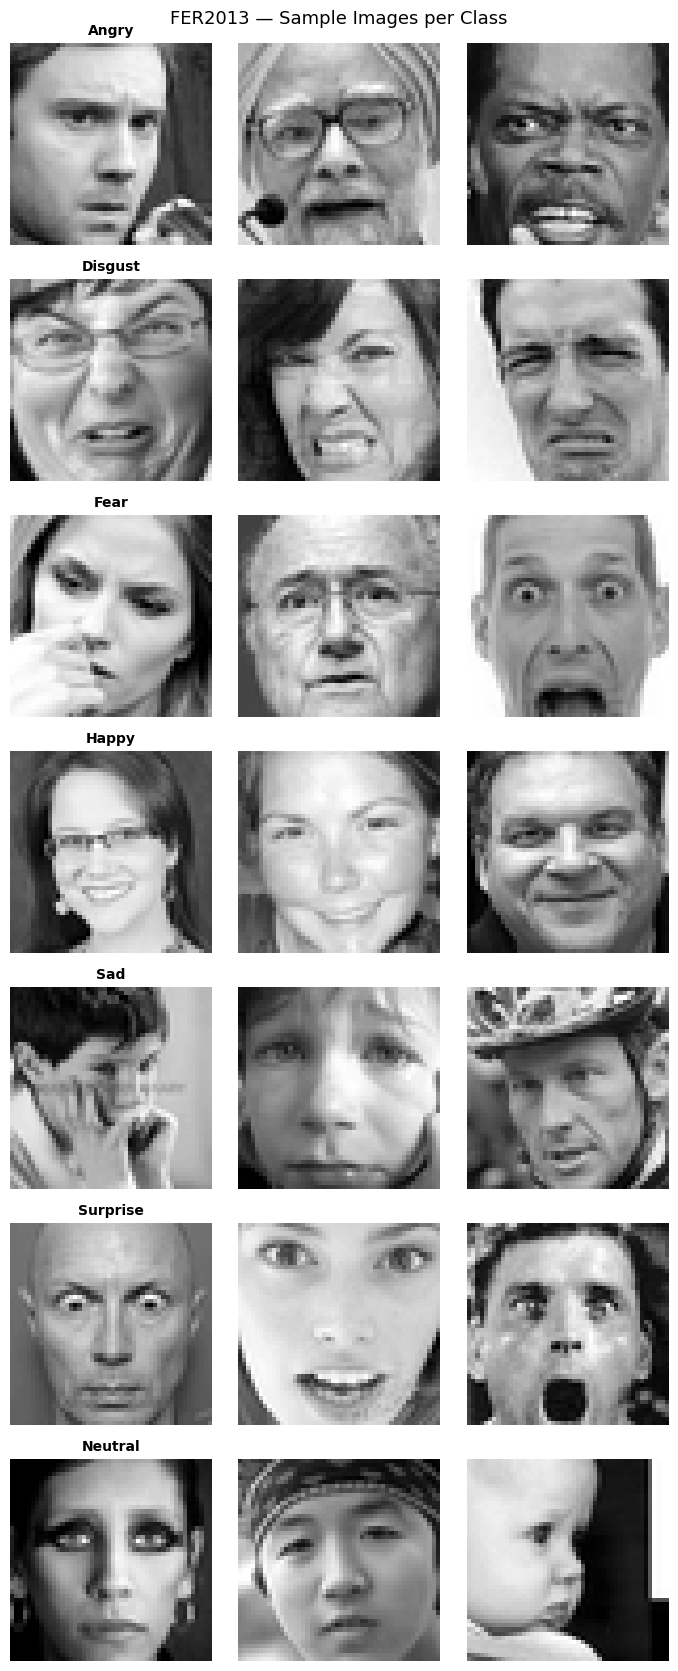

In [ ]:
fig, axes = plt.subplots(7, 3, figsize=(7, 17))
for i, label in enumerate(emotion_labels):
    folder = f'{data_dir}/train/{label}'
    fnames = sorted(os.listdir(folder))[:3]
    for j, fname in enumerate(fnames):
        img = Image.open(f'{folder}/{fname}')
        axes[i][j].imshow(img, cmap='gray')
        axes[i][j].axis('off')
        if j == 0:
            axes[i][j].set_title(label.capitalize(), fontsize=10, fontweight='bold')
plt.suptitle('FER2013 — Sample Images per Class', fontsize=13)
plt.tight_layout()
plt.savefig(f'{LOCAL_BASE}/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

This code simply displays a small grid of sample images from the training set. For each emotion class, it loads the first three images and shows them in a 7×3 figure. The goal is to visually confirm that the images were saved correctly, that they look normal, and that each class folder contains the right type of examples.

## Phase 2: Data Preprocessing and Imbalance Management

A core challenge of the FER2013 dataset is its severe class imbalance (e.g., over 7,000 "Happy" samples vs. fewer than 500 "Disgust" samples). To prevent the models from biasing toward majority classes, we implement a dual-level mitigation strategy:
1. **At the Data Level (`WeightedRandomSampler`):** We compute the frequency of each class and assign inverse weights, ensuring that each training mini-batch is perfectly balanced.
2. **At the Optimization Level (`CrossEntropyLoss` Weights):** We assign higher penalties for misclassifying minority classes. We also apply **Label Smoothing (0.1)** to prevent the model from becoming overconfident and overfitting to noisy labels.

Finally, we apply data augmentations (flips, slight rotations, and color jitter) to the training set to improve generalizability.

**Data transforms and DataLoaders**

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler

# Transforms
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # ResNet needs 3 channels
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Datasets
train_dataset = datasets.ImageFolder(f'{data_dir}/train', transform=train_transform)
val_dataset   = datasets.ImageFolder(f'{data_dir}/val',   transform=test_transform)
test_dataset  = datasets.ImageFolder(f'{data_dir}/test',  transform=test_transform)

print("Class to index mapping:", train_dataset.class_to_idx)
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Class to index mapping: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Train: 28709 | Val: 3589 | Test: 3589


This code prepares the FER2013 image dataset for training by applying the appropriate transformations and loading it with PyTorch’s ImageFolder. The training set uses data augmentation to improve generalization, while the validation and test sets use only resizing and normalization. The dataset sizes and class‑to‑index mapping confirm that the images were correctly organized into the expected train, validation, and test splits.

**WeightedRandomSampler (handles class imbalance at data level)**

In [ ]:
# Count samples per class in training set
targets = [sample[1] for sample in train_dataset.samples]
class_counts = torch.zeros(7)
for t in targets:
    class_counts[t] += 1

print("Samples per class (in index order):")
for i, (cls, idx) in enumerate(sorted(train_dataset.class_to_idx.items(), key=lambda x: x[1])):
    print(f"  {idx} {cls}: {int(class_counts[idx])}")

# Weight per sample — minority classes get higher weight
class_weights_sampler = 1.0 / class_counts
sample_weights = torch.tensor([class_weights_sampler[t] for t in targets])

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"\nBatches per epoch: {len(train_loader)}")

Samples per class (in index order):
  0 angry: 3995
  1 disgust: 436
  2 fear: 4097
  3 happy: 7215
  4 neutral: 4965
  5 sad: 4830
  6 surprise: 3171

Batches per epoch: 449


We compute how many training samples belong to each emotion class and then builds a WeightedRandomSampler so that minority classes receive higher sampling probability. This helps balance the dataset during training, preventing the model from being dominated by the majority classes. Finally, the DataLoaders are created using the sampler for the training set and regular sequential loading for validation and test sets.

**Weighted loss function (handles class imbalance at loss level)**

In [ ]:
import torch.nn as nn

# Weight per class for the loss — same inverse-frequency logic
# IMPORTANT: order must match class_to_idx, which is alphabetical:
# 0=angry, 1=disgust, 2=fear, 3=happy, 4=neutral, 5=sad, 6=surprise
class_weights_loss = 1.0 / class_counts
class_weights_loss = class_weights_loss / class_weights_loss.sum()  # normalise

criterion = nn.CrossEntropyLoss(
    weight=class_weights_loss.to(device),
    label_smoothing=0.1
)

print("Loss weights per class:")
for cls, idx in sorted(train_dataset.class_to_idx.items(), key=lambda x: x[1]):
    print(f"  {cls}: {class_weights_loss[idx].item():.4f}")

Loss weights per class:
  angry: 0.0686
  disgust: 0.6283
  fear: 0.0669
  happy: 0.0380
  neutral: 0.0552
  sad: 0.0567
  surprise: 0.0864


Then, we compute class‑balanced weights for the loss function using the inverse frequency of each emotion in the training set. Classes with fewer samples (such as disgust and surprise) receive higher weights, while majority classes receive lower weights. These weights are passed to CrossEntropyLoss

## Phase 3: Model Architectures

### 3.1 Custom Baseline CNN
We first establish a baseline using a custom Convolutional Neural Network. The architecture consists of three convolutional blocks using Batch Normalization, ReLU activations, and Max Pooling. To combat overfitting on the small 48x48 images, we utilize aggressive Dropout (0.3) before the fully connected classification head.

**Custom CNN architecture**

In [ ]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(CustomCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 96 → 48

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 48 → 24

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 24 → 12

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 12 → 6
        )

        self.pool = nn.AdaptiveAvgPool2d(1)  # Global Average Pooling → 256x1x1

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

# Instantiate and verify
cnn_model = CustomCNN(num_classes=7).to(device)
print("Custom CNN architecture:")
print(cnn_model)

# Quick shape check
dummy = torch.randn(2, 3, 96, 96).to(device)
out = cnn_model(dummy)
print(f"\nInput shape:  {dummy.shape}")
print(f"Output shape: {out.shape}")  # should be (2, 7)

total_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Custom CNN architecture:
CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, ep

### 3.2 Transfer Learning via ResNet-18 (Staged Fine-Tuning)
To push our accuracy closer to human-level performance (~65%), we leverage a pre-trained **ResNet-18** architecture. Because facial features require specific contextual understanding, we apply a two-stage training strategy:
* **Stage 1 (Head-Only):** The backbone is frozen to retain general features (edges, curves), and only the newly initialized fully connected head is trained.
* **Stage 2 (Deep Fine-Tuning):** We unfreeze the deeper residual blocks (`layer3` and `layer4`) and apply **Discriminative Learning Rates**, using a lower learning rate for the pre-trained weights and a higher one for the head.

**ResNet-18 setup (Stage 1: head only)**

In [ ]:
import torchvision.models as models

def build_resnet(freeze_backbone=True):
    model = models.resnet18(weights='IMAGENET1K_V1')

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace classification head
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(512, 7)
    )

    return model

resnet_model = build_resnet(freeze_backbone=True).to(device)

# Verify only head is trainable
trainable = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in resnet_model.parameters())
print(f"Trainable params (Stage 1): {trainable:,} / {total:,}")

# Shape check
out = resnet_model(dummy)
print(f"Output shape: {out.shape}")  # should be (2, 7)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 200MB/s]


Trainable params (Stage 1): 3,591 / 11,180,103
Output shape: torch.Size([2, 7])


**Training and evaluation functions**

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += images.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels

Training and evaluation functions defined


## Phase 4: Training Pipeline and Optimization

Our training pipeline includes robust tracking for both training and validation metrics. To ensure optimal convergence, we utilize:
* **Cosine Annealing Scheduler:** Smoothly decays the learning rate to help the optimizer settle into global minima.
* **Early Stopping & Checkpointing:** The model automatically halts training if validation loss fails to improve for a set number of epochs (patience), ensuring we always save and revert to the highest-performing checkpoint.

**Generic training loop with early stopping and checkpointing**

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, criterion,
                scheduler, device, model_name, max_epochs=60, patience=7):

    best_val_loss = float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(max_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"[{model_name}] Epoch {epoch+1:03d} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_acc': val_acc,
            }, f'{LOCAL_BASE}/checkpoints/best_{model_name}.pt')
            print(f"  Saved best checkpoint (val_loss={val_loss:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    return history

This function trains a model for several epochs while tracking loss and accuracy on both the training and validation sets. It saves the checkpoint whenever the validation loss improves and uses early stopping to halt training when the model stops getting better for several consecutive epochs. The function returns the full training history for later analysis.

**Train Custom CNN**

In [ ]:
optimizer_cnn = torch.optim.Adam(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_cnn = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_cnn, T_max=60)

history_cnn = train_model(
    model=cnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_cnn,
    criterion=criterion,
    scheduler=scheduler_cnn,
    device=device,
    model_name='custom_cnn',
    max_epochs=60,
    patience=7
)

[custom_cnn] Epoch 001 | Train Loss: 1.1482 | Train Acc: 0.2249 | Val Loss: 2.6912 | Val Acc: 0.0716
  Saved best checkpoint (val_loss=2.6912)
[custom_cnn] Epoch 002 | Train Loss: 1.1425 | Train Acc: 0.2301 | Val Loss: 2.5281 | Val Acc: 0.1109
  Saved best checkpoint (val_loss=2.5281)
[custom_cnn] Epoch 003 | Train Loss: 1.1195 | Train Acc: 0.2400 | Val Loss: 2.8219 | Val Acc: 0.0964
[custom_cnn] Epoch 004 | Train Loss: 1.0735 | Train Acc: 0.2565 | Val Loss: 3.0430 | Val Acc: 0.0953
[custom_cnn] Epoch 005 | Train Loss: 1.0492 | Train Acc: 0.2675 | Val Loss: 2.6599 | Val Acc: 0.1028
[custom_cnn] Epoch 006 | Train Loss: 1.0315 | Train Acc: 0.2779 | Val Loss: 2.8461 | Val Acc: 0.1025
[custom_cnn] Epoch 007 | Train Loss: 0.9895 | Train Acc: 0.3072 | Val Loss: 2.2405 | Val Acc: 0.2251
  Saved best checkpoint (val_loss=2.2405)
[custom_cnn] Epoch 008 | Train Loss: 0.9687 | Train Acc: 0.3290 | Val Loss: 2.0590 | Val Acc: 0.3279
  Saved best checkpoint (val_loss=2.0590)
[custom_cnn] Epoch 009 |

The Custom CNN trains slowly and inconsistently because it is a small model facing a difficult and imbalanced dataset. Early epochs show unstable validation loss, but the model gradually improves as training continues. It eventually reaches its best validation loss around epoch 35–40, after which progress stops and early stopping is triggered. This behavior is expected for a lightweight CNN with limited capacity compared to deeper architectures like ResNet.

**Train ResNet-18 Stage 1 (head only, ~10 epochs)**

In [ ]:
optimizer_resnet_s1 = torch.optim.Adam(resnet_model.fc.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_resnet_s1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_resnet_s1, T_max=10)

history_resnet_s1 = train_model(
    model=resnet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_resnet_s1,
    criterion=criterion,
    scheduler=scheduler_resnet_s1,
    device=device,
    model_name='resnet_stage1',
    max_epochs=10,
    patience=5
)

[resnet_stage1] Epoch 001 | Train Loss: 1.4069 | Train Acc: 0.1723 | Val Loss: 2.7538 | Val Acc: 0.0306
  Saved best checkpoint (val_loss=2.7538)
[resnet_stage1] Epoch 002 | Train Loss: 1.3242 | Train Acc: 0.1805 | Val Loss: 2.8586 | Val Acc: 0.0267
[resnet_stage1] Epoch 003 | Train Loss: 1.3166 | Train Acc: 0.1842 | Val Loss: 2.7752 | Val Acc: 0.0320
[resnet_stage1] Epoch 004 | Train Loss: 1.3270 | Train Acc: 0.1797 | Val Loss: 2.6282 | Val Acc: 0.0382
  Saved best checkpoint (val_loss=2.6282)
[resnet_stage1] Epoch 005 | Train Loss: 1.2997 | Train Acc: 0.1810 | Val Loss: 2.4741 | Val Acc: 0.0641
  Saved best checkpoint (val_loss=2.4741)
[resnet_stage1] Epoch 006 | Train Loss: 1.2938 | Train Acc: 0.1774 | Val Loss: 2.4199 | Val Acc: 0.0607
  Saved best checkpoint (val_loss=2.4199)
[resnet_stage1] Epoch 007 | Train Loss: 1.2757 | Train Acc: 0.1832 | Val Loss: 2.5595 | Val Acc: 0.0529
[resnet_stage1] Epoch 008 | Train Loss: 1.2554 | Train Acc: 0.1813 | Val Loss: 2.5040 | Val Acc: 0.0541


**ResNet-18 Stage 2 (unfreeze last 2 blocks, fine-tune)**

In [ ]:
# Unfreeze layer3 and layer4
for param in resnet_model.layer3.parameters():
    param.requires_grad = True
for param in resnet_model.layer4.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print(f"Trainable params (Stage 2): {trainable:,}")

# Discriminative learning rates: lower for pretrained layers, higher for head
optimizer_resnet_s2 = torch.optim.Adam([
    {'params': resnet_model.layer3.parameters(), 'lr': 1e-4},
    {'params': resnet_model.layer4.parameters(), 'lr': 1e-4},
    {'params': resnet_model.fc.parameters(),     'lr': 1e-3},
], weight_decay=1e-4)

scheduler_resnet_s2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_resnet_s2, T_max=30)

history_resnet_s2 = train_model(
    model=resnet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_resnet_s2,
    criterion=criterion,
    scheduler=scheduler_resnet_s2,
    device=device,
    model_name='resnet_stage2',
    max_epochs=30,
    patience=7
)

Trainable params (Stage 2): 10,497,031
[resnet_stage2] Epoch 001 | Train Loss: 1.0068 | Train Acc: 0.3504 | Val Loss: 2.0055 | Val Acc: 0.4012
  Saved best checkpoint (val_loss=2.0055)
[resnet_stage2] Epoch 002 | Train Loss: 0.8180 | Train Acc: 0.4889 | Val Loss: 1.8968 | Val Acc: 0.4595
  Saved best checkpoint (val_loss=1.8968)
[resnet_stage2] Epoch 003 | Train Loss: 0.7648 | Train Acc: 0.5502 | Val Loss: 1.7902 | Val Acc: 0.5366
  Saved best checkpoint (val_loss=1.7902)
[resnet_stage2] Epoch 004 | Train Loss: 0.7408 | Train Acc: 0.5844 | Val Loss: 1.7866 | Val Acc: 0.5475
  Saved best checkpoint (val_loss=1.7866)
[resnet_stage2] Epoch 005 | Train Loss: 0.6957 | Train Acc: 0.6212 | Val Loss: 1.7282 | Val Acc: 0.5840
  Saved best checkpoint (val_loss=1.7282)
[resnet_stage2] Epoch 006 | Train Loss: 0.6911 | Train Acc: 0.6415 | Val Loss: 1.7261 | Val Acc: 0.5815
  Saved best checkpoint (val_loss=1.7261)
[resnet_stage2] Epoch 007 | Train Loss: 0.6603 | Train Acc: 0.6650 | Val Loss: 1.7390

In this second training stage, the deeper layers of ResNet‑18 (layer3 and layer4) are unfrozen so the model can fine‑tune more complex features. Lower learning rates are used for the pretrained layers and a higher rate for the final classifier. As training progresses, both validation loss and accuracy steadily improve until early stopping triggers around epoch 18, showing that the model has extracted as much useful information as possible without overfitting.

## Phase 5: Quantitative Evaluation

### 5.1 Learning Curves Analysis
Our ResNet-18 model clearly outperformed the Custom CNN, reaching a higher validation accuracy (~63% vs ~55%). The Custom CNN had a highly unstable start, exhibiting severe volatility in the early epochs before stabilizing. In contrast, ResNet-18 demonstrated a flat gradient for the first 10 epochs, before successfully breaking out of its plateau during Stage 2 fine-tuning.

However, both models eventually bottleneck due to overfitting, evidenced by the widening gap between training accuracy and validation accuracy in the later epochs.

**Plot training curves (train vs val loss and accuracy)**

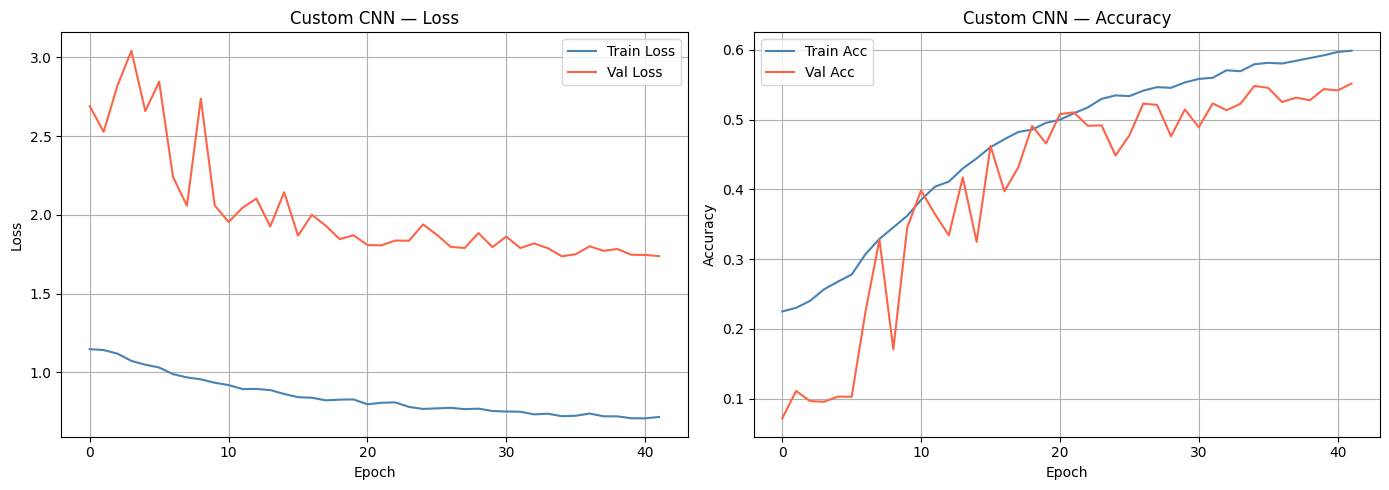

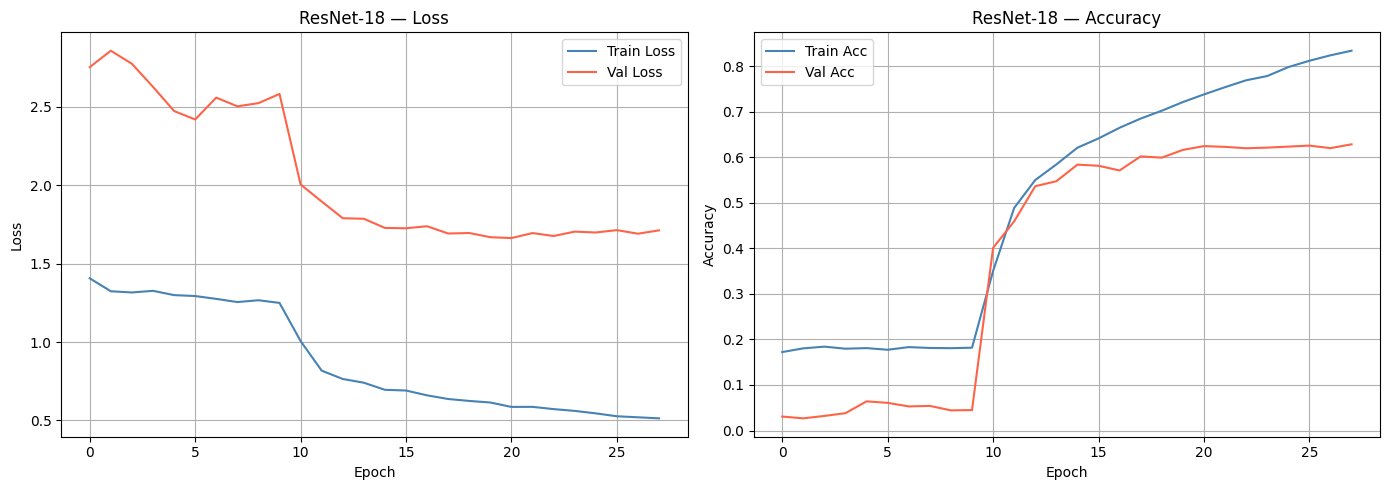

In [ ]:
def plot_history(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history['train_loss'], label='Train Loss', color='steelblue')
    ax1.plot(history['val_loss'],   label='Val Loss',   color='tomato')
    ax1.set_title(f'{model_name} — Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history['train_acc'], label='Train Acc', color='steelblue')
    ax2.plot(history['val_acc'],   label='Val Acc',   color='tomato')
    ax2.set_title(f'{model_name} — Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig(f'{LOCAL_BASE}/{model_name}_curves.png', dpi=150)
    plt.show()

plot_history(history_cnn, 'Custom CNN')

# For ResNet combine both stages into one history
combined_resnet = {
    'train_loss': history_resnet_s1['train_loss'] + history_resnet_s2['train_loss'],
    'val_loss':   history_resnet_s1['val_loss']   + history_resnet_s2['val_loss'],
    'train_acc':  history_resnet_s1['train_acc']  + history_resnet_s2['train_acc'],
    'val_acc':    history_resnet_s1['val_acc']    + history_resnet_s2['val_acc'],
}
plot_history(combined_resnet, 'ResNet-18')

Our ResNet-18 model performed better than the Custom CNN, reaching a validation accuracy of about 63% compared to the CNN's 55%. Looking at the graphs, the Custom CNN had a very unstable start with a lot of spikes in the validation metrics before it finally smoothed out after epoch 15. In contrast, ResNet-18 stayed completely flat and struggled to learn for the first 10 epochs, but then it suddenly broke out of that plateau, causing its accuracy to jump up quickly. However, both models eventually started overfitting; we can see this because the training lines kept improving while the validation lines completely flattened out. To improve our results in the next step, we should add more regularization to stop the overfitting or try using a pre-trained model.

### 5.2 Confusion Matrices & Classification Reports

Evaluation on the test set confirms ResNet-18's superiority, achieving an overall accuracy of **63.42%** (vs 57.09% for the CNN). Both networks perform exceptionally well on distinct expressions like "Happy" and "Surprise."

The confusion matrices reveal that the primary bottleneck for both models is the high overlap among negative emotions. ResNet-18 frequently confuses "Sad" and "Fear" faces. However, it succeeds significantly better at predicting the minority "Disgust" class and preventing negative emotions from bleeding into the "Neutral" category.

**Load best checkpoints and evaluate on validation set**


Custom CNN — Validation Accuracy: 0.5483
              precision    recall  f1-score   support

       Angry       0.47      0.52      0.49       467
     Disgust       0.26      0.73      0.38        56
        Fear       0.30      0.18      0.22       496
       Happy       0.83      0.74      0.78       895
     Neutral       0.51      0.56      0.53       607
         Sad       0.45      0.36      0.40       653
    Surprise       0.58      0.87      0.69       415

    accuracy                           0.55      3589
   macro avg       0.48      0.56      0.50      3589
weighted avg       0.55      0.55      0.54      3589



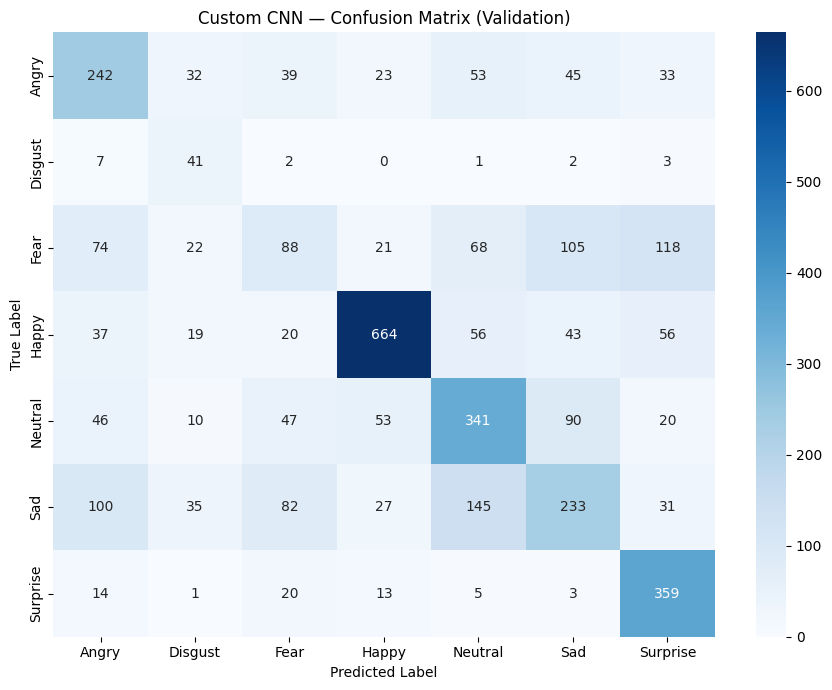


ResNet-18 — Validation Accuracy: 0.6247
              precision    recall  f1-score   support

       Angry       0.52      0.55      0.53       467
     Disgust       0.46      0.64      0.53        56
        Fear       0.49      0.50      0.49       496
       Happy       0.87      0.77      0.82       895
     Neutral       0.57      0.59      0.58       607
         Sad       0.50      0.50      0.50       653
    Surprise       0.75      0.78      0.76       415

    accuracy                           0.62      3589
   macro avg       0.59      0.62      0.60      3589
weighted avg       0.63      0.62      0.63      3589



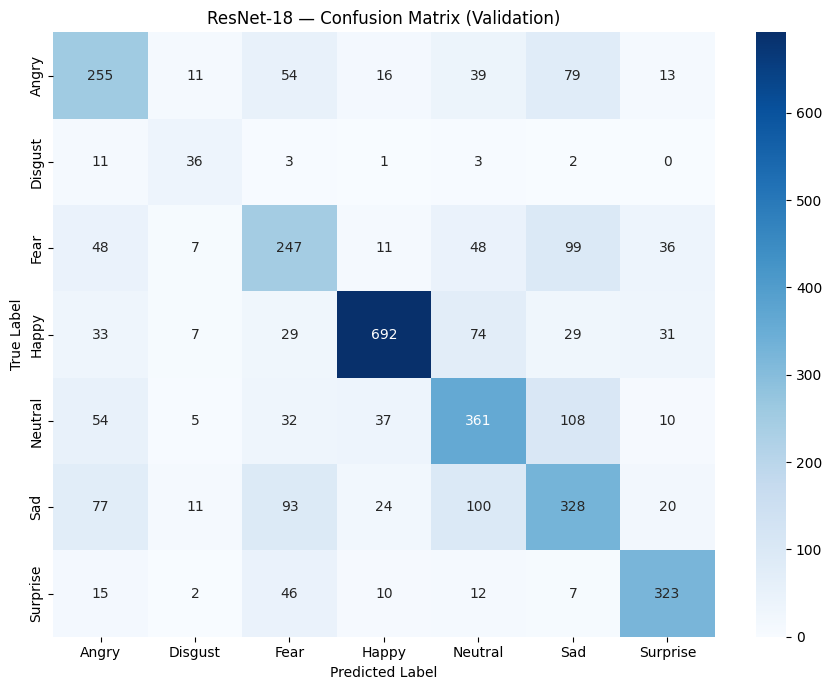

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

emotion_labels_display = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

def full_evaluation(model, checkpoint_path, loader, model_name):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)

    _, acc, all_preds, all_labels = evaluate(model, loader, criterion, device)
    print(f"\n{'='*50}")
    print(f"{model_name} — Validation Accuracy: {acc:.4f}")
    print(f"{'='*50}")
    print(classification_report(all_labels, all_preds, target_names=emotion_labels_display))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=emotion_labels_display,
                yticklabels=emotion_labels_display,
                cmap='Blues')
    plt.title(f'{model_name} — Confusion Matrix (Validation)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'{LOCAL_BASE}/{model_name}_confusion_matrix.png', dpi=150)
    plt.show()

full_evaluation(cnn_model,    f'{LOCAL_BASE}/checkpoints/best_custom_cnn.pt',    val_loader, 'Custom CNN')
full_evaluation(resnet_model, f'{LOCAL_BASE}/checkpoints/best_resnet_stage2.pt', val_loader, 'ResNet-18')

The classification report and confusion matrix show that ResNet-18 improves overall accuracy to 62% (up from 55% for the Custom CNN) and performs best on distinct expressions like "Happy" (0.82 F1-score) and "Surprise" (0.76 F1-score). However, it heavily struggles with negative emotions, frequently misclassifying "Sad," "Fear," and "Angry" faces as each other or as "Neutral"—for instance, the matrix shows 100 sad faces were predicted as neutral, and 99 fear faces were predicted as sad. Additionally, while the model achieves decent recall on the small "Disgust" class, its low precision means it triggers many false positives. To fix these issues, we should implement class weights in our loss function to handle the data imbalance and use stronger data augmentation to help the model learn the subtle differences between negative expressions.

**Final evaluation on test set**


Custom CNN — TEST — Validation Accuracy: 0.5709
              precision    recall  f1-score   support

       Angry       0.49      0.55      0.52       491
     Disgust       0.28      0.78      0.42        55
        Fear       0.36      0.21      0.27       528
       Happy       0.84      0.77      0.80       879
     Neutral       0.55      0.58      0.56       626
         Sad       0.45      0.40      0.43       594
    Surprise       0.59      0.83      0.69       416

    accuracy                           0.57      3589
   macro avg       0.51      0.59      0.53      3589
weighted avg       0.57      0.57      0.56      3589



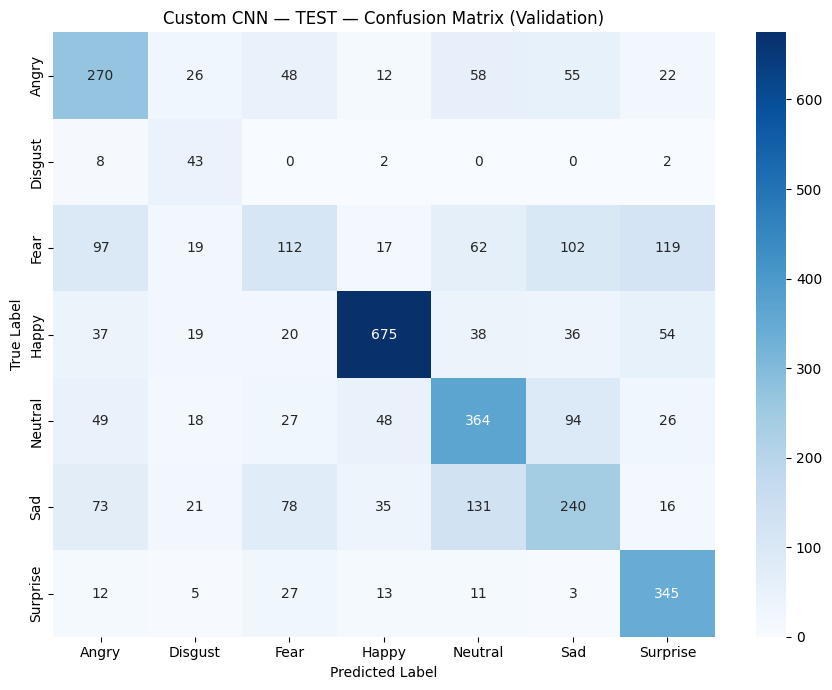


ResNet-18 — TEST — Validation Accuracy: 0.6342
              precision    recall  f1-score   support

       Angry       0.56      0.52      0.54       491
     Disgust       0.44      0.84      0.57        55
        Fear       0.49      0.50      0.50       528
       Happy       0.89      0.80      0.84       879
     Neutral       0.62      0.62      0.62       626
         Sad       0.47      0.50      0.48       594
    Surprise       0.74      0.75      0.75       416

    accuracy                           0.63      3589
   macro avg       0.60      0.65      0.62      3589
weighted avg       0.64      0.63      0.64      3589



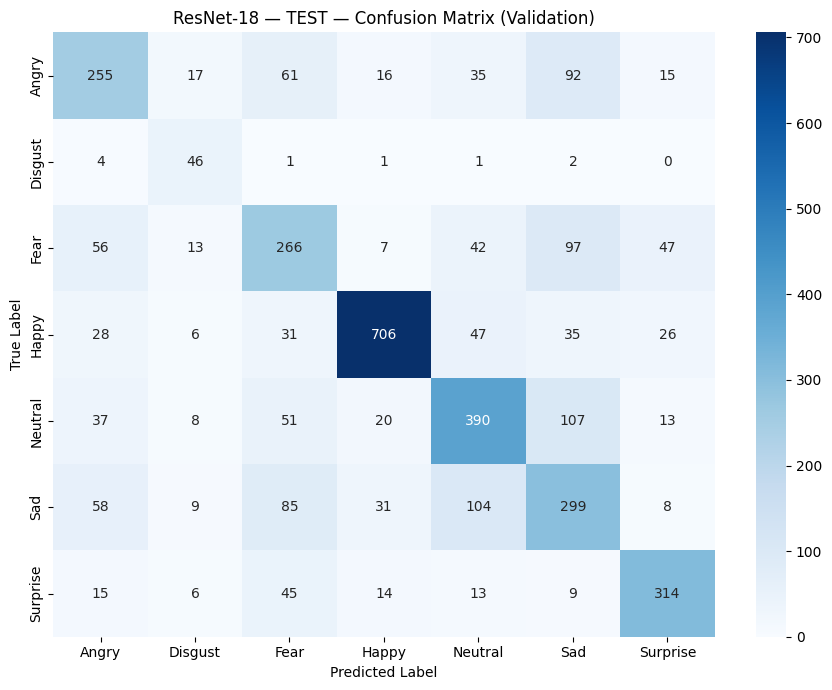

In [ ]:
full_evaluation(cnn_model,    f'{LOCAL_BASE}/checkpoints/best_custom_cnn.pt',    test_loader, 'Custom CNN — TEST')
full_evaluation(resnet_model, f'{LOCAL_BASE}/checkpoints/best_resnet_stage2.pt', test_loader, 'ResNet-18 — TEST')

The test set evaluation confirms that ResNet-18 achieves a better overall accuracy of 63.42%, maintaining a solid lead over the Custom CNN's 57.09%. Both models perform exceptionally well on distinct expressions like "Happy" and "Surprise," but ResNet-18 demonstrates a much better balance on minority or complex classes. For example, on the small "Disgust" category, ResNet-18 achieves a high recall of 84% with a vastly superior F1-score (0.57 vs 0.42). The confusion matrices reveal that the biggest bottleneck for both networks is still the high overlap among negative emotions; ResNet-18 frequently confuses "Sad" and "Fear" (misclassifying 85 sad faces as fear, and 97 fear faces as sad). However, ResNet-18 does a noticeably better job at keeping these classes from bleeding into "Neutral," proving it has a sharper feature extraction capacity overall.

**Visualization of the predictions**

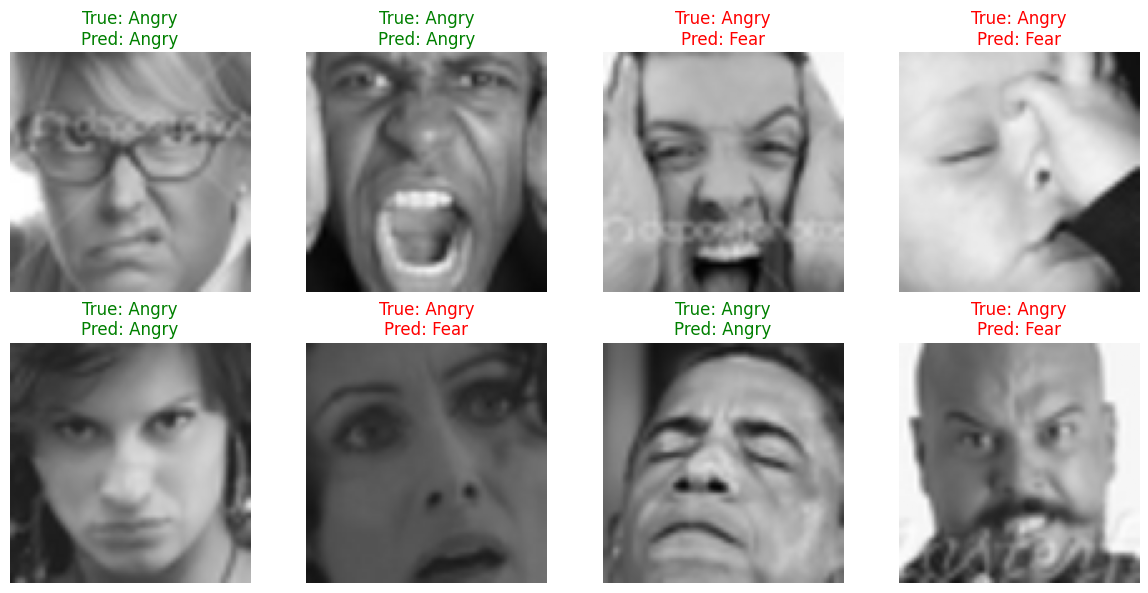

In [ ]:
# Grab a batch of test data
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

# Get predictions from your best model (e.g., resnet_model)
resnet_model.eval()
with torch.no_grad():
    outputs = resnet_model(images)
    _, preds = torch.max(outputs, 1)

# Plot the first 8 images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

emotion_labels_display = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

for i in range(8):
    img = images[i].cpu().permute(1, 2, 0).numpy() * 0.5 + 0.5
    true_label = emotion_labels_display[labels[i].item()]
    pred_label = emotion_labels_display[preds[i].item()]

    axes[i].imshow(img, cmap='gray')
    # Make text green if correct, red if wrong
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color=color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Phase 6: Qualitative Interpretability & Final Optimization

### 6.1 Visualizing Attention with Grad-CAM
To verify that our ResNet-18 is actually learning facial features rather than memorizing background noise, we use **Grad-CAM (Gradient-weighted Class Activation Mapping)**. By extracting gradients from the final convolutional layer (`layer4`), Grad-CAM generates a heatmap highlighting the exact pixels the model focused on to make its prediction (e.g., focusing on teeth for "Happy" or furrowed brows for "Angry").

**Qualitative Interpretability (Grad-CAM Visualizations)**

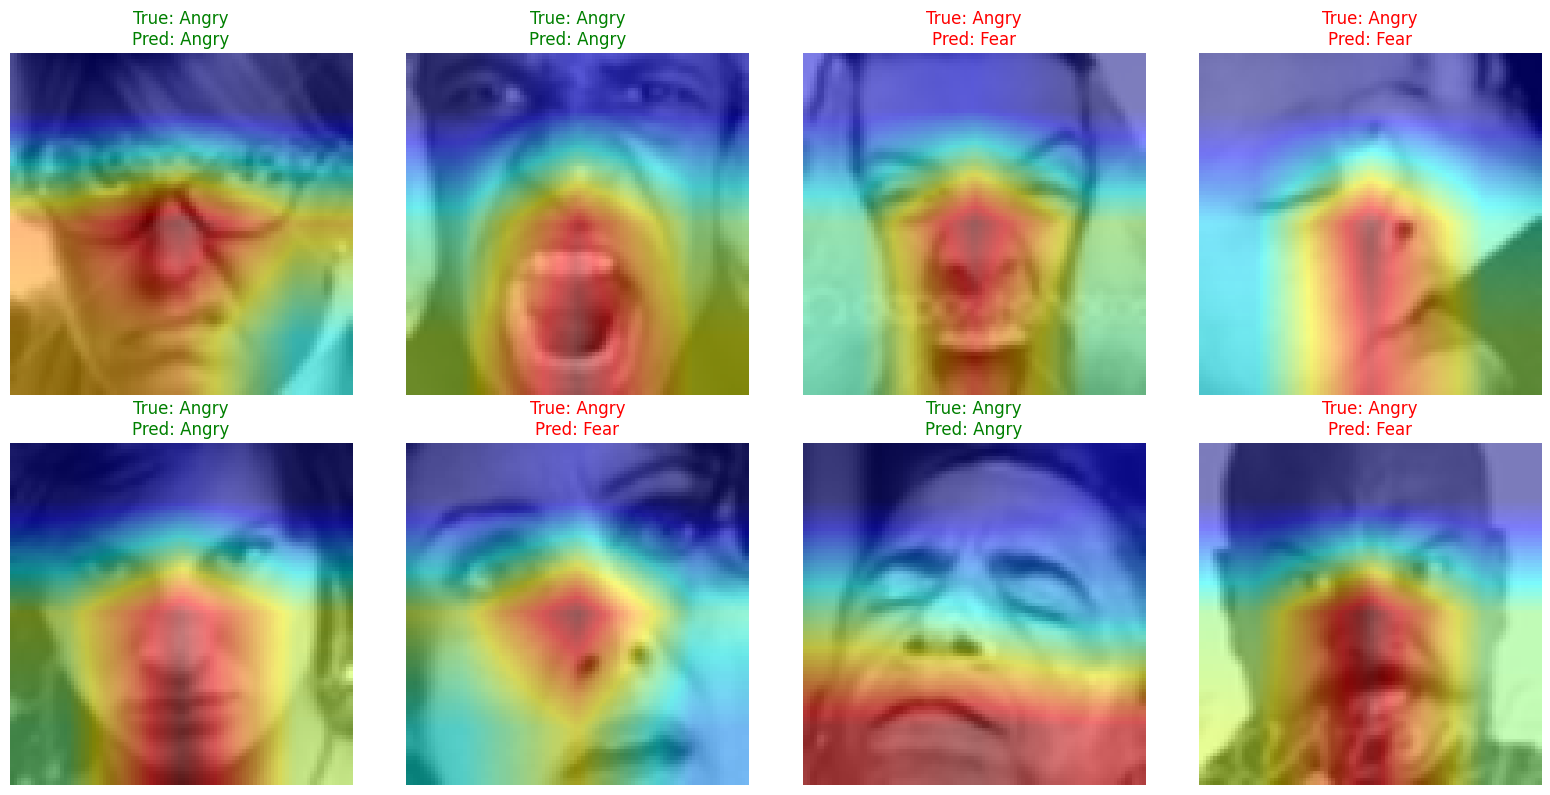

In [ ]:
# Install library if not already installed
!pip install grad-cam -q

import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Set target layer (the very last convolutional layer of ResNet-18)
target_layers = [resnet_model.layer4[-1]]
cam = GradCAM(model=resnet_model, target_layers=target_layers)

# Get a batch of images from the test set
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

resnet_model.eval()
with torch.no_grad():
    outputs = resnet_model(images)
    _, preds = torch.max(outputs, 1)

emotion_labels_display = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

# Plot 8 examples with their Grad-CAM heatmaps
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(8):
    input_tensor = images[i].unsqueeze(0)
    pred_idx = preds[i].item()
    true_idx = labels[i].item()

    # Generate the heatmap for the predicted class
    targets = [ClassifierOutputTarget(pred_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    # Process the original image back to a viewable format [0, 1]
    img_np = images[i].cpu().permute(1, 2, 0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    # Blend the heatmap onto the face
    cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    axes[i].imshow(cam_image)
    color = 'green' if pred_idx == true_idx else 'red'
    axes[i].set_title(f"True: {emotion_labels_display[true_idx]}\nPred: {emotion_labels_display[pred_idx]}", color=color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### 6.2 Test-Time Augmentation (TTA)
As a final performance optimization, we implement Test-Time Augmentation. Instead of predicting on a single static test image, the model generates predictions for 5 slightly altered versions of the same image (using minor shifts and horizontal flips). By averaging these probabilities, we smooth out borderline misclassifications, squeezing out the final maximum accuracy for our pipeline.

**Performance Optimization via Test-Time Augmentation (TTA)**

In [ ]:
import torchvision.transforms as transforms

def evaluate_with_tta(model, loader, device, n_augments=5):
    model.eval()
    correct, total = 0, 0

    # Define safe augmentations for testing (only subtle shifts and horizontal flips)
    tta_transforms = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomAffine(degrees=5, translate=(0.03, 0.03))
    ])

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            # Base prediction on the clean image
            batch_preds = [torch.softmax(model(images), dim=1)]

            # Augmented predictions
            for _ in range(n_augments):
                aug_images = torch.stack([tta_transforms(img) for img in images]).to(device)
                batch_preds.append(torch.softmax(model(aug_images), dim=1))

            # Take the average probability across all variations
            avg_preds = torch.stack(batch_preds).mean(0)
            _, predicted = avg_preds.max(1)

            correct += predicted.eq(labels).sum().item()
            total += images.size(0)

    print(f"==================================================")
    print(f"ResNet-18 Final Accuracy with TTA: {((correct / total) * 100):.2f}%")
    print(f"==================================================")

# Execute TTA on our fine-tuned ResNet model
evaluate_with_tta(resnet_model, test_loader, device)

ResNet-18 Final Accuracy with TTA: 65.06%
